# Whisper — quick-start: AT2017GFO with a *custom* model

A hands-on tour of [`whisper_labia`](https://github.com/phelipedarc/WHISPER_AI) on the kilonova
**AT2017GFO**: load a light curve → inspect → plot → define **your own model** → fit it with ABC →
compare models → (optional) run **SNPE**.

Whisper runs standalone — its data handling, samplers, likelihoods and plots are its own. Physical
models + priors can *optionally* be plugged in from the external **redback** package, but nothing here
needs it.

> Run the cells top to bottom. Inference cells use `n_jobs=1` so they work in any notebook; a
> module-level model function (in a `.py`) can use `n_jobs>1` for parallel ABC.

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import whisper_labia as wp

print("whisper_labia", wp.__version__)
print("samplers:", wp.list_samplers())
print("built-in models:", wp.list_models())

whisper_labia 0.0.1.dev0
samplers: ['abc', 'abc_smc', 'npe', 'snpe']
built-in models: ['bazin', 'flare', 'gaussian_rise']


## 1. Load the light curve

`load_lightcurve` auto-detects the columns (time / magnitude or flux / band / errors), normalizes band
names, applies quality cuts, and resolves each band's effective wavelength + zero point. AT2017GFO sits
in NGC 4993 at redshift **z ≈ 0.0098**.

In [5]:
csv = next(p for p in [Path("../tests/data/at2017gfo.csv"),
                       Path("tests/data/at2017gfo.csv"),
                       Path("whisper-labia/tests/data/at2017gfo.csv")] if p.exists())

lc = wp.load_lightcurve(csv, redshift=0.0098)
print(lc)
print("n_bands:", len(lc.bands), "| data_mode:", lc.data_mode, "| redshift_known:", lc.redshift_known)

LightCurve(name='at2017gfo', n_points=645, bands=['B', 'C', 'F110W', 'F160W', 'F336W', 'F475W', 'F606W', 'F625W', 'F775W', 'F814W', 'F850W', 'H', 'I', 'J', 'J1', 'K', 'Ks', 'R', 'U', 'V', 'W', 'Y', 'g', 'i', 'r', 'u', 'w', 'y', 'z'], mode='magnitude', z=0.0098)
n_bands: 29 | data_mode: magnitude | redshift_known: True


/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:176: UserWarning: Band 'C' is not in FILTER_LOOKUP; attempting SVO fallback.
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:176: UserWarning: Could not resolve band 'C' via SVO (No documented SVO filter ID for band 'C' and no wavelength hint to search with. Pass register_manual_band(...) or a lambda_eff hint.). Effective wavelength / zero point are unknown; supply them with whisper_labia.io.svo.register_manual_band('C', lambda_eff, zero_point).
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:176: UserWarning: Band 'W' is not in FILTER_LOOKUP; attempting SVO fallback.
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:17

### The light curve as a table

Calling the object (`lc()`) returns the **enriched** dataframe — both flux and magnitude are filled in
from the per-band zero point, alongside `lambda_eff`, `zero_point` and `snr`:

In [6]:
lc().head()

,time,band,magnitude,magnitude_err,flux,system,lambda_eff,zero_point,snr
0,57982.981400,i,17.4800,0.02,0.000370,AB,7545.0,3631.0,54.286810
1,57982.990200,H,18.2600,0.15,0.000180,AB,16620.0,3631.0,7.238241
2,57982.991991,C,17.3335,0.06,0.000423,unknown,NaN,NaN,18.095603
3,57982.993000,r,17.4600,0.03,0.000377,AB,6215.0,3631.0,36.191207
4,57982.999000,Ks,18.6200,0.05,0.000129,AB,21590.0,3631.0,21.714724


## 2. Plot it

Report layout: apparent magnitude **and** flux density, all bands overlaid.

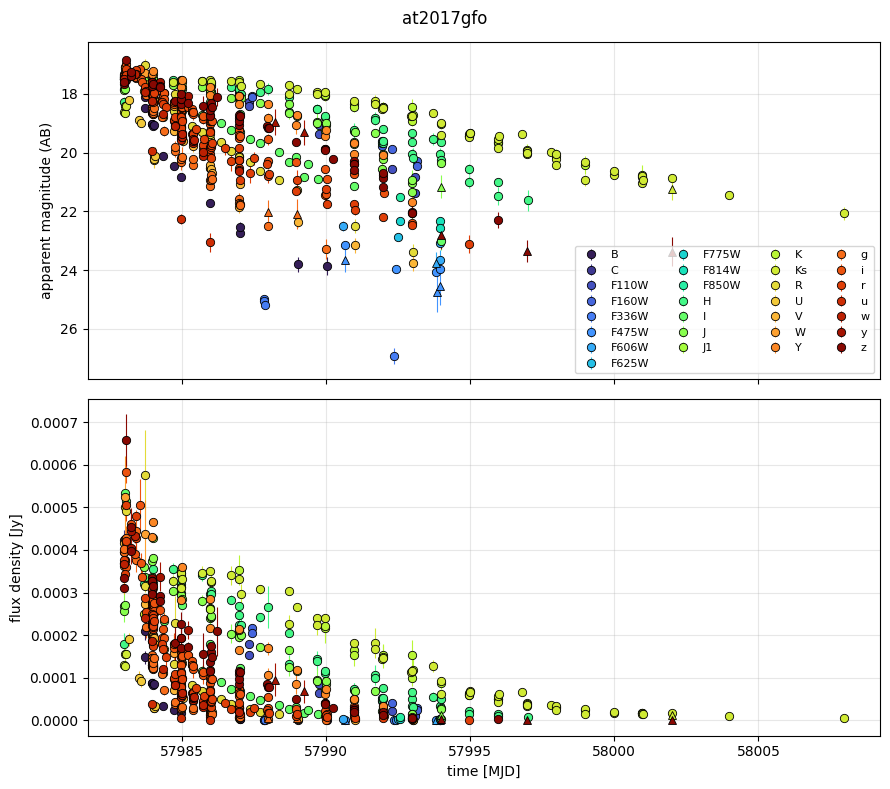

In [7]:
wp.plot_light_curve(lc, layout="report")
plt.show()

## 3. Focus on the r-band, measured from explosion

We set the explosion epoch (MJD 57982 → day 0), keep points with SNR ≥ 3, and select the r-band.

In [8]:
r = (wp.load_lightcurve(csv, redshift=0.0098, explosion_date=57982.0, min_snr=3)
       .select_bands("r"))
print(r.n_points, "r-band points; t =",
      round(float(r.time.min()), 2), "to", round(float(r.time.max()), 2), "days")

88 r-band points; t = 0.99 to 12.97 days


/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:176: UserWarning: Band 'C' is not in FILTER_LOOKUP; attempting SVO fallback.
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:176: UserWarning: Could not resolve band 'C' via SVO (No documented SVO filter ID for band 'C' and no wavelength hint to search with. Pass register_manual_band(...) or a lambda_eff hint.). Effective wavelength / zero point are unknown; supply them with whisper_labia.io.svo.register_manual_band('C', lambda_eff, zero_point).
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:176: UserWarning: Band 'W' is not in FILTER_LOOKUP; attempting SVO fallback.
  info[key] = resolve_band(key, lookup=lookup, svo_fallback=svo_fallback, warn=warn)
/opt/conda/lib/python3.11/site-packages/whisper_labia/io/bands.py:17

## 4. Define your **own** model

A Whisper model is just a function `predict(params, times, bands) -> flux (Jy)`. Register it once and it
works with **every** sampler. Here we add a *stretched exponential*,

$$ f(t) = A \, \exp\!\left[-\left(t/\tau\right)^{\beta}\right] $$

with a prior on each parameter (`LogUniform` for the positive amplitude scale, `Uniform` otherwise).

In [9]:
def stretched_exp(params, times, bands=None):
    """Custom transient model: A * exp(-(t/tau)**beta), flux in Jy."""
    t = np.clip(np.asarray(times, dtype=float), 0.0, None)
    return params["amplitude"] * np.exp(-(t / params["tau"]) ** params["beta"])

wp.register_model(
    "stretched_exp", stretched_exp, ["amplitude", "tau", "beta"],
    prior=wp.Prior({"amplitude": wp.LogUniform(1e-5, 1e-2),
                    "tau":       wp.Uniform(0.5, 10.0),
                    "beta":      wp.Uniform(0.3, 2.5)}),
    description="A * exp(-(t/tau)^beta)", overwrite=True)

print("models now:", wp.list_models())

models now: ['bazin', 'flare', 'gaussian_rise', 'stretched_exp']


## 5. Fit the custom model with ABC

Approximate Bayesian Computation: draw parameters from the prior → simulate the light curve → keep the
draws closest to the data. The result carries a posterior summary and model-selection metrics.

In [10]:
res = wp.fit_ABC(r, "stretched_exp", n_simulations=60000, quantile=0.01, n_jobs=1, seed=0)
print(res)
for p, s in res.summary.items():
    print(f"  {p:10s} = {s['median']:.3g}  [{s['ci16']:.3g}, {s['ci84']:.3g}]")

SamplerResult(sampler='abc', model='stretched_exp', n_samples=600, AIC=4331.2, runtime=2.32s)
  amplitude  = 0.000417  [0.000271, 0.000792]
  tau        = 2.54  [1.45, 3.29]
  beta       = 1.47  [0.955, 2.07]


### Plot the fit (best-fit + posterior draws)

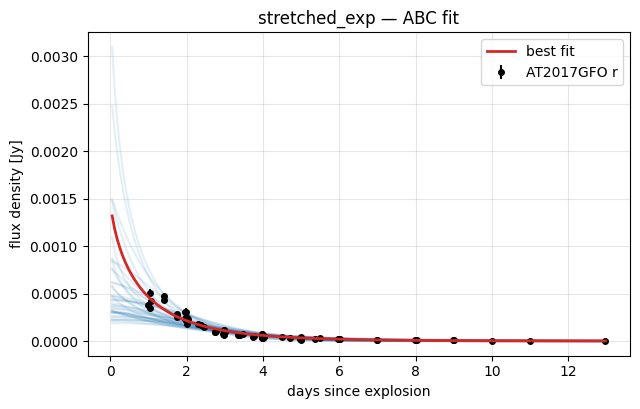

In [11]:
from whisper_labia.models import get_model
model = get_model("stretched_exp")
tt = np.linspace(0.05, float(r.time.max()), 200)
rf = r.add_flux()

plt.figure(figsize=(7, 4.2))
plt.errorbar(rf.time, rf.flux, yerr=rf.flux_err, fmt="o", ms=4, color="black", label="AT2017GFO r", zorder=3)
for row in res.samples[res.parameters].sample(n=40, random_state=0).to_numpy():
    plt.plot(tt, model.predict(dict(zip(res.parameters, row)), tt, None), color="C0", alpha=0.12, zorder=1)
plt.plot(tt, model.predict(res.best_params, tt, None), color="C3", lw=2, label="best fit", zorder=4)
plt.xlabel("days since explosion"); plt.ylabel("flux density [Jy]")
plt.title("stretched_exp — ABC fit"); plt.legend(); plt.grid(alpha=0.3); plt.show()

## 6. Compare with a built-in model

Fit the built-in `flare` model the same way and compare by AIC / BIC (lower = preferred, on the same
data). This is the core "which model best fits?" question Whisper is built for.

In [ ]:
res_flare = wp.fit_ABC(r, "flare", n_simulations=60000, quantile=0.01, n_jobs=1, seed=0)
print(f"{'model':14s} {'AIC':>8s} {'BIC':>8s}")
for rr in (res, res_flare):
    print(f"{rr.model:14s} {rr.aic:8.1f} {rr.bic:8.1f}")

## 7. (Optional) Neural posterior estimation — SNPE

SNPE trains a neural density estimator instead of using an explicit likelihood. It needs the optional
`[sbi]` extra (`pip install 'whisper-labia[sbi]'`) and reuses the **same** model + prior. `num_rounds>1`
focuses simulations sequentially.

In [ ]:
res_snpe = wp.fit_SNPE(r, "stretched_exp", num_rounds=2, num_simulations=1500,
                       num_samples=4000, space="flux", seed=0)
print(res_snpe)

import corner
corner.corner(res_snpe.samples[res_snpe.parameters].to_numpy(),
              labels=res_snpe.parameters, show_titles=True)
plt.show()

For richer, high-dimensional / multi-band problems, `fit_SNPE` also accepts a custom
`embedding_net` (a `torch.nn.Module`), a custom `density_estimator` (or `posterior_nn` hyperparameters
`hidden_features` / `num_transforms` / `num_bins`), and `proposal_mode="restricted"` for **truncated
SNPE**. See `docs/API_REFERENCE.md`.

## Next steps
- Try other samplers: `wp.fit_ABC_SMC`, `wp.fit(..., sampler="npe")`.
- Fit multiple bands, add upper limits, or register a physically-motivated model.
- Bring physical models + priors from the optional redback `[models]` extra.
- Full docs: `docs/TUTORIAL.md`, `docs/API_REFERENCE.md`.